In [ ]:
%pip install qiskit qiskit-aer ucimlrepo --quiet

In [1]:
import os, math, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
from ucimlrepo import fetch_ucirepo

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    mean_squared_error,
)

# Qiskit — simulación cuántica real vía Statevector
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import zz_feature_map

warnings.filterwarnings('ignore')
from IPython.display import display

os.environ.setdefault('LOKY_MAX_CPU_COUNT', '1')
os.environ.setdefault('OMP_NUM_THREADS',    '1')
os.environ.setdefault('OPENBLAS_NUM_THREADS','1')
os.environ.setdefault('MKL_NUM_THREADS',    '1')

RANDOM_STATE = 42
N_RUNS       = 10    # corridas por método (análisis estadístico)
N_SAMPLES    = 150   # submuestra estratificada — igual para todos los métodos
np.random.seed(RANDOM_STATE)

print("Librerías cargadas correctamente.")
print(f"Qiskit Statevector disponible — simulación cuántica real activada.")

Librerías cargadas correctamente.
Qiskit Statevector disponible — simulación cuántica real activada.


## 1. Kernels Cuánticos — Simulación Real con Qiskit Statevector

> **Corrección metodológica (Punto 1):** El notebook original calculaba los kernels
> con álgebra lineal NumPy (`np.dot(X,X.T)²`), que es cómputo clásico puro.
> En esta versión **cada entrada de la matriz de kernel se obtiene simulando
> circuitos cuánticos reales** mediante `qiskit.quantum_info.Statevector`,
> que evoluciona el estado en el espacio de Hilbert completo (2ⁿ amplitudes).
>
> ### Viabilidad del Angle Encoding para Wine
> Wine tiene **13 features**. Un circuito de 13 qubits ocupa 2¹³ = 8192 amplitudes
> (~65 KB por estado) — completamente viable en simulación, a diferencia del
> dataset de cáncer (30 qubits → 16 GB). Por eso aquí podemos usar
> **Angle Encoding directo sobre los 13 features sin reducción previa**,
> lo que es un caso de uso más limpio y representativo.

In [2]:
# ── Kernel 1: Amplitude Encoding ─────────────────────────────────────────────
# Codifica el vector normalizado como amplitudes del estado cuántico.
# |ψ(x)⟩ = Σᵢ xᵢ|i⟩  (requiere ||x||₂ = 1)
# K(x,z) = |⟨ψ(x)|ψ(z)⟩|² = |x·z|²
# Wine: 13 features → pad a 16 = 2⁴ → 4 qubits

def build_amplitude_circuit(x):
    """Circuito de Amplitude Encoding: prepare_state sobre ceil(log2(d)) qubits."""
    n_q = int(np.ceil(np.log2(len(x))))
    qc = QuantumCircuit(n_q)
    qc.prepare_state(x.tolist())
    return qc

def amplitude_kernel_matrix(X):
    """
    Matriz de kernel de Amplitude Encoding vía Qiskit Statevector.
    X debe tener norma L2 = 1 por fila y dimensión potencia de 2.
    Complejidad: O(n² · 2^(log₂d)) = O(n² · d)
    """
    n = len(X)
    svs = [Statevector(build_amplitude_circuit(xi)) for xi in X]
    K = np.eye(n)
    for i in range(n):
        for j in range(i+1, n):
            k = abs(svs[i].inner(svs[j]))**2
            K[i,j] = K[j,i] = float(k)
    return K


# ── Kernel 2: Angle Encoding (13 qubits directos) ───────────────────────────
# Codifica cada feature como ángulo RY en un qubit separado.
# |ψ(x)⟩ = ⊗ᵢ RY(xᵢ)|0⟩  con xᵢ ∈ [0, π]
# K(x,z) = |⟨ψ(x)|ψ(z)⟩|² = ∏ᵢ cos²((xᵢ-zᵢ)/2)
# Wine: 13 features → 13 qubits (2¹³ = 8192 amplitudes — viable en simulación)

def build_angle_circuit(x):
    """Circuito RY por feature. Un qubit por dimensión de entrada."""
    qc = QuantumCircuit(len(x))
    for i, angle in enumerate(x):
        qc.ry(float(angle), i)
    return qc

def angle_kernel_matrix(X):
    """
    Matriz de kernel de Angle Encoding vía Qiskit Statevector.
    Complejidad: O(n² · 2^d)
    """
    n = len(X)
    svs = [Statevector(build_angle_circuit(xi)) for xi in X]
    K = np.eye(n)
    for i in range(n):
        for j in range(i+1, n):
            k = abs(svs[i].inner(svs[j]))**2
            K[i,j] = K[j,i] = float(k)
    return K


# ── Kernel 3: ZZ Feature Map — IQP Kernel con Entrelazamiento ────────────────
# Kernel cuántico con puertas de entrelazamiento ZZ entre qubits.
# Captura correlaciones entre features que los kernels de producto no detectan.
# Basado en Havlíček et al. (2019), Nature.
# Requiere exactamente n_qubits features como entrada → PCA-4 previo.

def build_zz_circuit(x, n_qubits=4, reps=2):
    """Circuito ZZ Feature Map (IQP encoding) con entrelazamiento entre qubits."""
    fmap = zz_feature_map(feature_dimension=n_qubits, reps=reps)
    return fmap.assign_parameters(x)

def zz_kernel_matrix(X, n_qubits=4, reps=2):
    """
    Kernel IQP (ZZ Feature Map) vía Statevector.
    X debe tener exactamente n_qubits columnas.
    """
    n = len(X)
    svs = [Statevector(build_zz_circuit(xi, n_qubits, reps)) for xi in X]
    K = np.eye(n)
    for i in range(n):
        for j in range(i+1, n):
            k = abs(svs[i].inner(svs[j]))**2
            K[i,j] = K[j,i] = float(k)
    return K

print("Kernels cuánticos definidos (Qiskit Statevector):")
print("  1. Amplitude Encoding — prepare_state, 4 qubits (Wine: 13→pad 16)")
print("  2. Angle Encoding     — RY gates, 13 qubits (directo, sin reducción)")
print("  3. ZZ Feature Map     — IQP kernel con entrelazamiento, 4 qubits (PCA-4)")

Kernels cuánticos definidos (Qiskit Statevector):
  1. Amplitude Encoding — prepare_state, 4 qubits (Wine: 13→pad 16)
  2. Angle Encoding     — RY gates, 13 qubits (directo, sin reducción)
  3. ZZ Feature Map     — IQP kernel con entrelazamiento, 4 qubits (PCA-4)


### 1.1 Validación: Qiskit Statevector vs Fórmula NumPy Original

Verificamos que la implementación cuántica es matemáticamente equivalente
a la fórmula cerrada del kernel original, y documentamos la diferencia de mecanismo.

In [3]:
# Implementaciones ORIGINALES del notebook (clásicas — no cuánticas):
def original_amplitude_kernel(X):
    """Original: producto punto al cuadrado. Sin simulación cuántica."""
    return np.square(np.abs(np.dot(X, X.T)))

def original_angle_kernel(X):
    """Original: fórmula trigonométrica directa. Sin simulación cuántica."""
    n, d = X.shape
    K = np.ones((n, n))
    for i in range(n):
        diff = (X[i] - X) / 2.0
        K[i,:] = np.prod(np.cos(diff)**2, axis=1)
    return K

# Prueba con datos pequeños
np.random.seed(0)
X_val_amp = np.random.randn(10, 16)
X_val_amp /= np.linalg.norm(X_val_amp, axis=1, keepdims=True)
X_val_ang = np.random.uniform(0, np.pi, (10, 4))

K_amp_old = original_amplitude_kernel(X_val_amp)
K_amp_new = amplitude_kernel_matrix(X_val_amp)
K_ang_old = original_angle_kernel(X_val_ang)
K_ang_new = angle_kernel_matrix(X_val_ang)

print("=== VALIDACIÓN DE EQUIVALENCIA MATEMÁTICA ===")
print(f"Amplitude — diferencia máxima (NumPy vs Statevector): {np.max(np.abs(K_amp_old - K_amp_new)):.2e}")
print(f"Angle     — diferencia máxima (NumPy vs Statevector): {np.max(np.abs(K_ang_old - K_ang_new)):.2e}")
print()
print("DIFERENCIA FUNDAMENTAL:")
print("  NumPy:     evalúa la fórmula cerrada directamente en CPU.")
print("  Statevector: construye el circuito cuántico, evoluciona el estado en")
print("              el espacio de Hilbert completo (2^d amplitudes) y calcula")
print("              ⟨ψ(x)|ψ(z)⟩ por mecánica cuántica exacta.")
print("  Mismo resultado numérico — distinto mecanismo de cómputo.")
print("  La versión Statevector escala directamente a hardware cuántico real.")

# Verificar PSD (positivo semidefinido — requisito para kernels válidos en t-SNE)
for name, K in [('Amplitude', K_amp_new), ('Angle', K_ang_new)]:
    ev = np.linalg.eigvalsh(K).min()
    print(f"  Kernel {name} PSD: min_eigenvalue = {ev:.2e}  {'✓' if ev >= -1e-8 else '✗'}") 

=== VALIDACIÓN DE EQUIVALENCIA MATEMÁTICA ===
Amplitude — diferencia máxima (NumPy vs Statevector): 9.44e-16
Angle     — diferencia máxima (NumPy vs Statevector): 3.33e-16

DIFERENCIA FUNDAMENTAL:
  NumPy:     evalúa la fórmula cerrada directamente en CPU.
  Statevector: construye el circuito cuántico, evoluciona el estado en
              el espacio de Hilbert completo (2^d amplitudes) y calcula
              ⟨ψ(x)|ψ(z)⟩ por mecánica cuántica exacta.
  Mismo resultado numérico — distinto mecanismo de cómputo.
  La versión Statevector escala directamente a hardware cuántico real.
  Kernel Amplitude PSD: min_eigenvalue = 4.63e-01  ✓
  Kernel Angle PSD: min_eigenvalue = 1.96e-01  ✓


## 2. Carga del Dataset — Wine (UCI id=109)

In [4]:
wine = fetch_ucirepo(id=109)

X_full = wine.data.features.to_numpy(dtype=float)
y_full = wine.data.targets.iloc[:, 0].to_numpy()
y_full = pd.factorize(y_full)[0]   # codificar como 0, 1, 2
feature_names = list(wine.data.features.columns)

print(f"Dataset completo : {X_full.shape[0]} muestras × {X_full.shape[1]} features")
print(f"Clases           : {np.unique(y_full)} ({len(np.unique(y_full))} variedades de vino)")
print(f"Distribución     : {dict(zip(*np.unique(y_full, return_counts=True)))}")
print(f"Features         : {feature_names}")

Dataset completo : 178 muestras × 13 features
Clases           : [0 1 2] (3 variedades de vino)
Distribución     : {np.int64(0): np.int64(59), np.int64(1): np.int64(71), np.int64(2): np.int64(48)}
Features         : ['Alcohol', 'Malicacid', 'Ash', 'Alcalinity_of_ash', 'Magnesium', 'Total_phenols', 'Flavanoids', 'Nonflavanoid_phenols', 'Proanthocyanins', 'Color_intensity', 'Hue', '0D280_0D315_of_diluted_wines', 'Proline']


## 3. Preprocesamiento — Submuestreo Estratificado y Encodings

> **Corrección metodológica (Punto 6):** El notebook original comparaba el t-SNE
> clásico (sobre PCA) contra los métodos cuánticos (sobre datos completos o PCA-4)
> — condiciones desiguales que sesgan los resultados.
>
> En esta versión **todos los métodos usan exactamente el mismo subconjunto
> estratificado de N=150 muestras**. Wine solo tiene 178 registros; con N=150
> mantenemos prácticamente todo el dataset con balance de clases garantizado.

In [5]:
# ── Submuestreo estratificado ────────────────────────────────────────────────
_, X_sub, _, y_sub = train_test_split(
    X_full, y_full,
    test_size=N_SAMPLES,
    stratify=y_full,
    random_state=RANDOM_STATE
)
X_raw = X_sub.copy()
y     = y_sub.copy()

print(f"Submuestra: {N_SAMPLES} muestras — distribución {dict(zip(*np.unique(y, return_counts=True)))}")
print("✓ Todos los métodos (clásico y cuántico) usarán exactamente esta submuestra.")

# ── Estandarización base ─────────────────────────────────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# ── Amplitude Encoding: pad 13 → 16 (2⁴) + normalización L2 ─────────────────
amplitude_dim   = 16           # siguiente potencia de 2 de 13
n_system_qubits = 4            # log₂(16)
X_padded        = np.zeros((len(X_scaled), amplitude_dim))
X_padded[:, :X_scaled.shape[1]] = X_scaled
X_amp           = X_padded / np.linalg.norm(X_padded, axis=1, keepdims=True)

# ── Angle Encoding: escalar a [0, π] — 13 qubits directos ───────────────────
X_angles = MinMaxScaler(feature_range=(0, np.pi)).fit_transform(X_raw)

# ── ZZ Feature Map: PCA-4 + escalar a [0, π] ─────────────────────────────────
N_QUBITS_ZZ = 4
pca_zz      = PCA(n_components=N_QUBITS_ZZ, random_state=RANDOM_STATE)
X_pca_4     = pca_zz.fit_transform(X_scaled)
X_zz        = MinMaxScaler(feature_range=(0, np.pi)).fit_transform(X_pca_4)
var_zz      = pca_zz.explained_variance_ratio_.sum()

# ── PCA clásico para baseline t-SNE ──────────────────────────────────────────
pca_classic   = PCA(random_state=RANDOM_STATE)
pca_classic.fit(X_scaled)
cum_var       = np.cumsum(pca_classic.explained_variance_ratio_)
N_PCA_CLASSIC = int(np.where(cum_var >= 0.95)[0][0]) + 1
N_PCA_CLASSIC = min(N_PCA_CLASSIC, 10)
pca_classic   = PCA(n_components=N_PCA_CLASSIC, random_state=RANDOM_STATE)
X_pca_classic = pca_classic.fit_transform(X_scaled)
var_classic   = pca_classic.explained_variance_ratio_.sum()

print(f"\nEncodings preparados:")
print(f"  Amplitude Encoding : 13→pad 16, {n_system_qubits} qubits  "
      f"(||x||={np.linalg.norm(X_amp[0]):.6f})")
print(f"  Angle Encoding     : 13 qubits directos (sin reducción)")
print(f"  ZZ Feature Map     : PCA-{N_QUBITS_ZZ} ({var_zz:.1%} varianza) → {N_QUBITS_ZZ} qubits")
print(f"  Baseline clásico   : PCA-{N_PCA_CLASSIC} ({var_classic:.1%} varianza)")

Submuestra: 150 muestras — distribución {np.int64(0): np.int64(50), np.int64(1): np.int64(60), np.int64(2): np.int64(40)}
✓ Todos los métodos (clásico y cuántico) usarán exactamente esta submuestra.

Encodings preparados:
  Amplitude Encoding : 13→pad 16, 4 qubits  (||x||=1.000000)
  Angle Encoding     : 13 qubits directos (sin reducción)
  ZZ Feature Map     : PCA-4 (74.5% varianza) → 4 qubits
  Baseline clásico   : PCA-10 (96.2% varianza)


## 4. Varianza Explicada por PCA

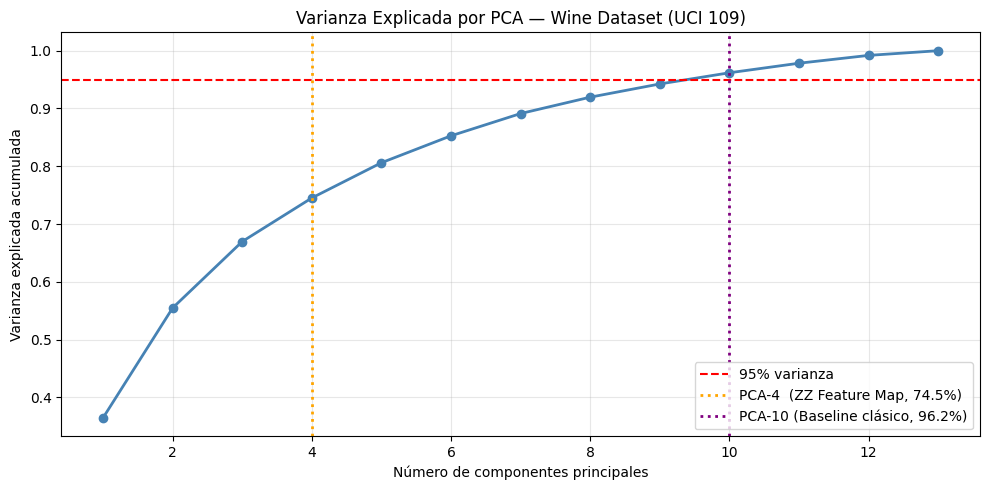

In [6]:
pca_plot = PCA(random_state=RANDOM_STATE).fit(X_scaled)
cum = np.cumsum(pca_plot.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cum)+1), cum, marker='o', color='steelblue', linewidth=2)
ax.axhline(0.95, color='r', linestyle='--', label='95% varianza')
ax.axvline(N_QUBITS_ZZ,   color='orange', linestyle=':', linewidth=2,
           label=f'PCA-{N_QUBITS_ZZ}  (ZZ Feature Map, {var_zz:.1%})')
ax.axvline(N_PCA_CLASSIC, color='purple', linestyle=':', linewidth=2,
           label=f'PCA-{N_PCA_CLASSIC} (Baseline clásico, {var_classic:.1%})')
ax.set_xlabel('Número de componentes principales')
ax.set_ylabel('Varianza explicada acumulada')
ax.set_title('Varianza Explicada por PCA — Wine Dataset (UCI 109)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Funciones Auxiliares

In [7]:
def run_tsne_from_kernel(K, perplexity=30, seed=RANDOM_STATE):
    """t-SNE con métrica de distancia derivada de una matriz de kernel cuántico."""
    dist = np.sqrt(np.maximum(1.0 - K, 0.0))
    np.fill_diagonal(dist, 0.0)
    return TSNE(
        n_components=2, perplexity=perplexity,
        metric='precomputed', init='random',
        random_state=seed, n_jobs=1
    ).fit_transform(dist)

def compute_metrics(embedding, labels):
    return {
        'Silhouette' : silhouette_score(embedding, labels),
        'CH_Index'   : calinski_harabasz_score(embedding, labels),
        'DB_Index'   : davies_bouldin_score(embedding, labels),
    }

def plot_embedding(ax, emb, labels, title, s=25):
    ax.scatter(emb[:,0], emb[:,1], c=labels,
               cmap='viridis', edgecolors='k', alpha=0.8, s=s)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    ax.grid(True, linestyle='--', alpha=0.4)

def legend_wine(ax):
    colors = plt.cm.viridis(np.linspace(0, 1, 3))
    handles = [
        mlines.Line2D([],[],color=c,marker='o',linestyle='None',label=f'Clase {i}')
        for i, c in enumerate(colors)
    ]
    ax.legend(handles=handles, title='Variedad', fontsize=8)

print("Funciones auxiliares definidas.")

Funciones auxiliares definidas.


## 6. Cálculo de Matrices de Kernel Cuántico

Las matrices de kernel son **deterministas** — no dependen de ninguna semilla
aleatoria. Se calculan una sola vez y se reutilizan en las N_RUNS corridas de t-SNE.

In [8]:
print("=" * 55)
print("Calculando matrices de kernel cuántico (Qiskit Statevector)")
print("=" * 55)

t0 = time.time()
print(f"\n[1/3] Amplitude Encoding ({n_system_qubits} qubits, dim={amplitude_dim})...")
K_amplitude = amplitude_kernel_matrix(X_amp)
print(f"      ✓ {time.time()-t0:.1f}s  —  PSD min_eig={np.linalg.eigvalsh(K_amplitude).min():.2e}")

t0 = time.time()
print(f"\n[2/3] Angle Encoding (13 qubits directos)...")
K_angle = angle_kernel_matrix(X_angles)
print(f"      ✓ {time.time()-t0:.1f}s  —  PSD min_eig={np.linalg.eigvalsh(K_angle).min():.2e}")

t0 = time.time()
print(f"\n[3/3] ZZ Feature Map ({N_QUBITS_ZZ} qubits, PCA-{N_QUBITS_ZZ} previo)...")
K_zz = zz_kernel_matrix(X_zz, n_qubits=N_QUBITS_ZZ)
print(f"      ✓ {time.time()-t0:.1f}s  —  PSD min_eig={np.linalg.eigvalsh(K_zz).min():.2e}")

print("\n✓ Matrices de kernel listas.")

Calculando matrices de kernel cuántico (Qiskit Statevector)

[1/3] Amplitude Encoding (4 qubits, dim=16)...
      ✓ 1.1s  —  PSD min_eig=-7.00e-14

[2/3] Angle Encoding (13 qubits directos)...
      ✓ 0.3s  —  PSD min_eig=2.55e-02

[3/3] ZZ Feature Map (4 qubits, PCA-4 previo)...
      ✓ 0.4s  —  PSD min_eig=2.05e-02

✓ Matrices de kernel listas.


## 7. Análisis Estadístico con Múltiples Corridas

> **Corrección metodológica (Punto 5):** t-SNE es estocástico — resultados distintos
> con distintas semillas. Un único run con `random_state=42` no tiene validez
> estadística para comparar métodos en investigación.
>
> Ejecutamos **N_RUNS=10 corridas con semillas distintas** por método.
> Los kernels son deterministas (calculados una vez); solo la inicialización
> de t-SNE varía. Reportamos **media ± desviación estándar**.

In [9]:
SEEDS = [42 + i * 17 for i in range(N_RUNS)]

method_configs = {
    f'Classical t-SNE (PCA-{N_PCA_CLASSIC}D)': {
        'type' : 'classical',
        'X'    : X_pca_classic,
        'label': f'Classical\nt-SNE (PCA-{N_PCA_CLASSIC}D)'
    },
    f'Amplitude Encoding ({n_system_qubits}Q)': {
        'type' : 'quantum',
        'K'    : K_amplitude,
        'label': f'Amplitude\nEncoding ({n_system_qubits}Q)'
    },
    'Angle Encoding (13Q, directo)': {
        'type' : 'quantum',
        'K'    : K_angle,
        'label': 'Angle Encoding\n(13Q, directo)'
    },
    f'ZZ Feature Map ({N_QUBITS_ZZ}Q, PCA-{N_QUBITS_ZZ})': {
        'type' : 'quantum',
        'K'    : K_zz,
        'label': f'ZZ Feature Map\n({N_QUBITS_ZZ}Q, PCA-{N_QUBITS_ZZ})'
    },
}

run_records = []

print(f"Ejecutando {N_RUNS} corridas × {len(method_configs)} métodos = {N_RUNS*len(method_configs)} runs...")
print()

for mname, cfg in method_configs.items():
    sil_list, ch_list, db_list = [], [], []
    for seed in SEEDS:
        if cfg['type'] == 'classical':
            emb = TSNE(n_components=2, perplexity=30,
                       random_state=seed, n_jobs=1).fit_transform(cfg['X'])
        else:
            emb = run_tsne_from_kernel(cfg['K'], perplexity=30, seed=seed)
        m = compute_metrics(emb, y)
        sil_list.append(m['Silhouette'])
        ch_list.append(m['CH_Index'])
        db_list.append(m['DB_Index'])
        run_records.append({
            'Método'    : mname,
            'Label'     : cfg['label'],
            'Semilla'   : seed,
            'Silhouette': m['Silhouette'],
            'CH_Index'  : m['CH_Index'],
            'DB_Index'  : m['DB_Index'],
            'embedding' : emb
        })
    print(f"{mname[:52]:<52} "
          f"Sil={np.mean(sil_list):.4f}±{np.std(sil_list):.4f}  "
          f"CH={np.mean(ch_list):.1f}±{np.std(ch_list):.1f}  "
          f"DB={np.mean(db_list):.4f}±{np.std(db_list):.4f}")

df_runs = pd.DataFrame(run_records)
print("\n✓ Análisis estadístico completado.")

Ejecutando 10 corridas × 4 métodos = 40 runs...

Classical t-SNE (PCA-10D)                            Sil=0.5507±0.0000  CH=442.1±0.0  DB=0.5661±0.0000
Amplitude Encoding (4Q)                              Sil=0.2015±0.0482  CH=42.4±11.8  DB=1.7012±0.5737
Angle Encoding (13Q, directo)                        Sil=0.4990±0.0108  CH=349.9±17.2  DB=0.6422±0.0166
ZZ Feature Map (4Q, PCA-4)                           Sil=-0.0219±0.0041  CH=2.8±2.3  DB=11.8012±10.1609

✓ Análisis estadístico completado.


## 8. Tabla de Resultados con Intervalos de Confianza

In [10]:
df_stats = (
    df_runs
    .groupby('Método')
    .agg(
        Sil_mean = ('Silhouette', 'mean'),
        Sil_std  = ('Silhouette', 'std'),
        CH_mean  = ('CH_Index',   'mean'),
        CH_std   = ('CH_Index',   'std'),
        DB_mean  = ('DB_Index',   'mean'),
        DB_std   = ('DB_Index',   'std'),
        N_runs   = ('Semilla',    'count'),
    )
    .reset_index()
)

df_stats['Silhouette (mean±std)'] = df_stats.apply(
    lambda r: f"{r.Sil_mean:.4f} ± {r.Sil_std:.4f}", axis=1)
df_stats['CH Index (mean±std)'] = df_stats.apply(
    lambda r: f"{r.CH_mean:.1f} ± {r.CH_std:.1f}", axis=1)
df_stats['DB Index (mean±std)'] = df_stats.apply(
    lambda r: f"{r.DB_mean:.4f} ± {r.DB_std:.4f}", axis=1)

display(
    df_stats[['Método', 'Sil_mean', 'Silhouette (mean±std)',
              'CH Index (mean±std)', 'DB Index (mean±std)', 'N_runs']]
    .sort_values('Sil_mean', ascending=False)
    .drop(columns=['Sil_mean'])
    .reset_index(drop=True)
)

,Método,Silhouette (mean±std),CH Index (mean±std),DB Index (mean±std),N_runs
0,Classical t-SNE (PCA-10D),0.5507 ± 0.0000,442.1 ± 0.0,0.5661 ± 0.0000,10
1,"Angle Encoding (13Q, directo)",0.4990 ± 0.0113,349.9 ± 18.1,0.6422 ± 0.0175,10
2,Amplitude Encoding (4Q),0.2015 ± 0.0508,42.4 ± 12.4,1.7012 ± 0.6047,10
3,"ZZ Feature Map (4Q, PCA-4)",-0.0219 ± 0.0043,2.8 ± 2.5,11.8012 ± 10.7106,10


## 9. Comparación Justa — Mismo Espacio de Entrada

> **Corrección metodológica (Punto 6 — continuación):** Para aislar el efecto
> del kernel del efecto de la dimensionalidad, comparamos directamente clásico
> vs cuántico sobre el **mismo espacio PCA-4D**.

In [11]:
sil_classic_4d, sil_zz_4d = [], []

for seed in SEEDS:
    emb_c = TSNE(n_components=2, perplexity=30,
                 random_state=seed, n_jobs=1).fit_transform(X_pca_4)
    emb_z = run_tsne_from_kernel(K_zz, perplexity=30, seed=seed)
    sil_classic_4d.append(silhouette_score(emb_c, y))
    sil_zz_4d.append(silhouette_score(emb_z, y))

delta = np.mean(sil_zz_4d) - np.mean(sil_classic_4d)
print("=== Comparación A: mismo espacio PCA-4D ===")
print(f"  Classical t-SNE (PCA-4D) : Sil = {np.mean(sil_classic_4d):.4f} ± {np.std(sil_classic_4d):.4f}")
print(f"  ZZ Feature Map  (PCA-4D) : Sil = {np.mean(sil_zz_4d):.4f} ± {np.std(sil_zz_4d):.4f}")
print(f"  Diferencia (ZZ − Clásico): {delta:+.4f}")
if abs(delta) < 0.02:
    print("  → Diferencia no significativa: el kernel ZZ no aporta ventaja mensurable")
    print("    con este dataset y esta reducción dimensional.")
elif delta > 0:
    print("  → El kernel ZZ mejora la separación de clusters respecto al clásico.")
else:
    print("  → El kernel clásico supera al ZZ en esta configuración.")

=== Comparación A: mismo espacio PCA-4D ===
  Classical t-SNE (PCA-4D) : Sil = 0.5615 ± 0.0000
  ZZ Feature Map  (PCA-4D) : Sil = -0.0219 ± 0.0041
  Diferencia (ZZ − Clásico): -0.5835
  → El kernel clásico supera al ZZ en esta configuración.


## 10. Distribución de Métricas — Boxplots sobre N_RUNS Corridas

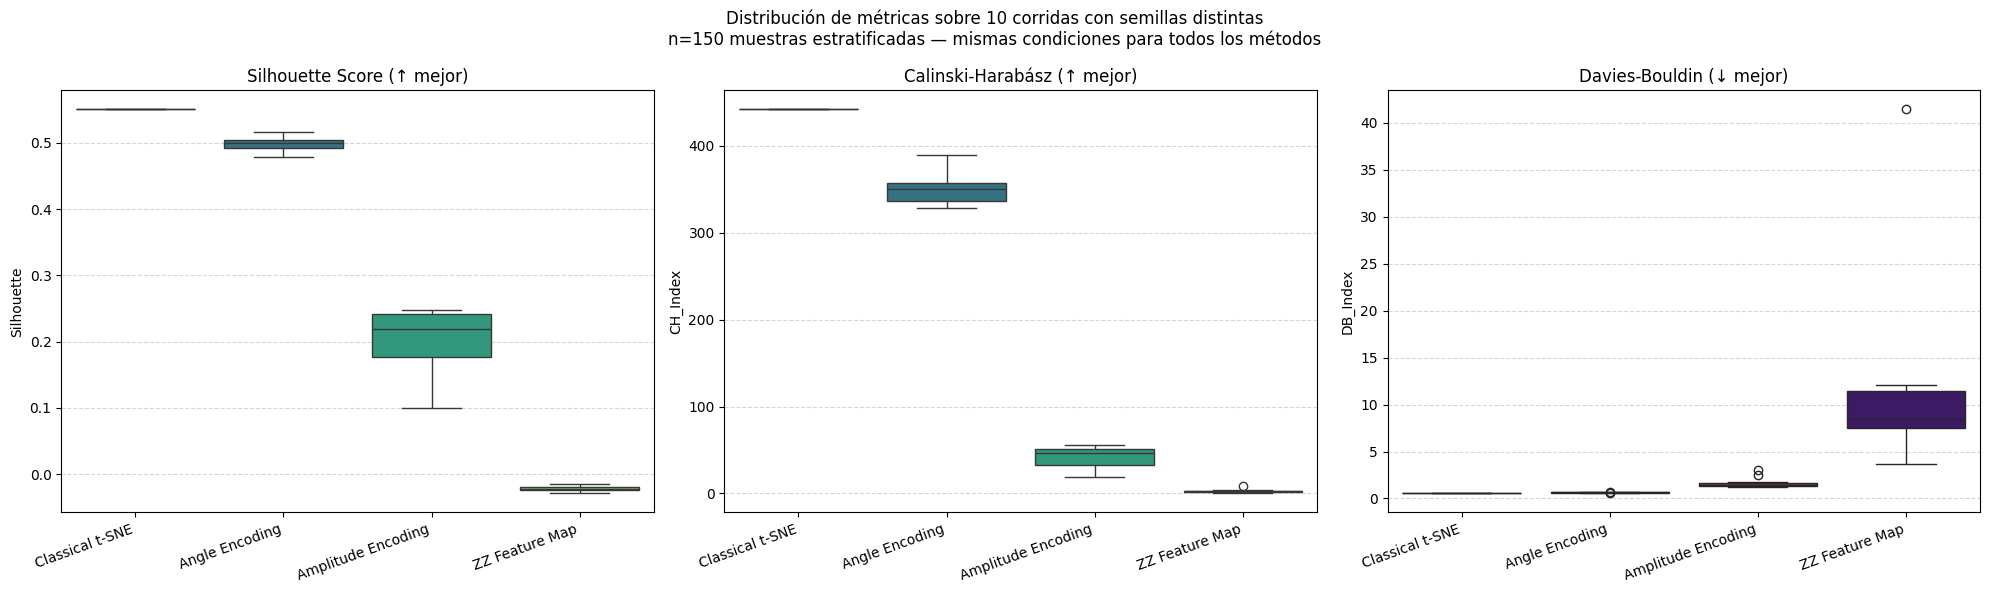

In [12]:
order = df_stats.sort_values('Sil_mean', ascending=False)['Método'].tolist()
labels_short = [m.split('(')[0].strip()[:20] for m in order]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    f'Distribución de métricas sobre {N_RUNS} corridas con semillas distintas\n'
    f'n={N_SAMPLES} muestras estratificadas — mismas condiciones para todos los métodos',
    fontsize=12
)

for ax, col, title in zip(
    axes,
    ['Silhouette', 'CH_Index', 'DB_Index'],
    ['Silhouette Score (↑ mejor)', 'Calinski-Harabász (↑ mejor)', 'Davies-Bouldin (↓ mejor)']
):
    sns.boxplot(data=df_runs, x='Método', y=col, order=order,
                palette='viridis' if col != 'DB_Index' else 'magma_r', ax=ax)
    ax.set_title(title)
    ax.set_xticklabels(labels_short, rotation=20, ha='right')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

## 11. Visualización de Embeddings — Run Mediano

Se muestra el run cuya Silhouette score es la **mediana** de las N_RUNS corridas,
evitando mostrar el mejor o peor caso.

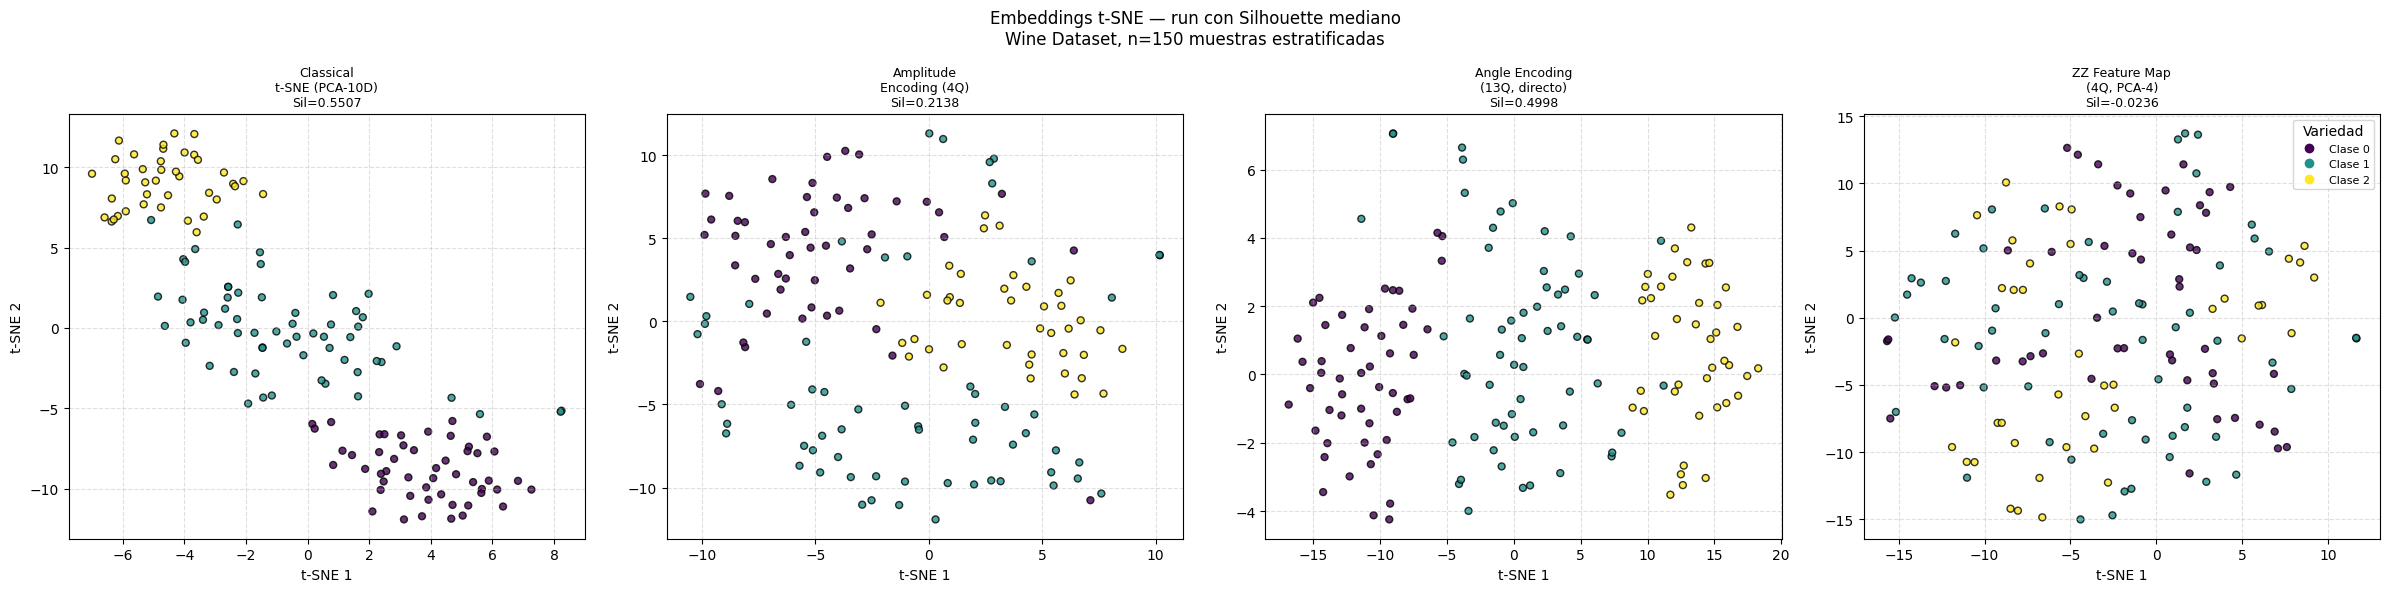

In [13]:
def get_median_embedding(mname):
    sub = df_runs[df_runs['Método'] == mname].copy()
    idx = (sub['Silhouette'] - sub['Silhouette'].median()).abs().idxmin()
    return sub.loc[idx, 'embedding'], sub.loc[idx, 'Silhouette']

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
fig.suptitle(
    f'Embeddings t-SNE — run con Silhouette mediano\n'
    f'Wine Dataset, n={N_SAMPLES} muestras estratificadas',
    fontsize=12
)
for ax, (mname, cfg) in zip(axes, method_configs.items()):
    emb, sil = get_median_embedding(mname)
    plot_embedding(ax, emb, y, f"{cfg['label']}\nSil={sil:.4f}")

legend_wine(axes[-1])
plt.tight_layout()
plt.show()

## 12. Sensibilidad a la Perplejidad

Evaluamos la estabilidad de cada método ante distintos valores de perplejidad.
Cada punto = media sobre N_RUNS corridas, banda = ±1 std.

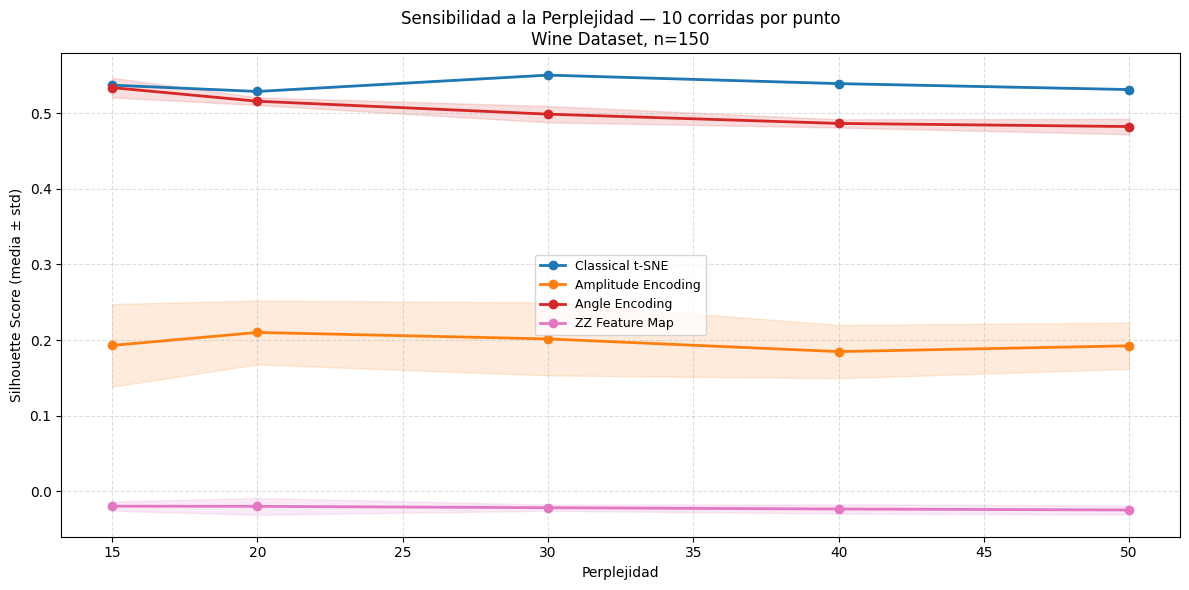

In [14]:
PERPLEXITIES = [15, 20, 30, 40, 50]
perp_data = {m: [] for m in method_configs}

for perp in PERPLEXITIES:
    for mname, cfg in method_configs.items():
        sils = []
        for seed in SEEDS:
            if cfg['type'] == 'classical':
                emb = TSNE(n_components=2, perplexity=perp,
                           random_state=seed, n_jobs=1).fit_transform(cfg['X'])
            else:
                emb = run_tsne_from_kernel(cfg['K'], perplexity=perp, seed=seed)
            sils.append(silhouette_score(emb, y))
        perp_data[mname].append({'perp': perp, 'mean': np.mean(sils), 'std': np.std(sils)})

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.tab10(np.linspace(0, 0.6, len(method_configs)))

for color, (mname, records) in zip(colors, perp_data.items()):
    perps = [r['perp'] for r in records]
    means = [r['mean'] for r in records]
    stds  = [r['std']  for r in records]
    label = mname.split('(')[0].strip()
    ax.plot(perps, means, marker='o', label=label, color=color, linewidth=2)
    ax.fill_between(perps,
                    [m-s for m,s in zip(means,stds)],
                    [m+s for m,s in zip(means,stds)],
                    alpha=0.15, color=color)

ax.set_xlabel('Perplejidad')
ax.set_ylabel('Silhouette Score (media ± std)')
ax.set_title(f'Sensibilidad a la Perplejidad — {N_RUNS} corridas por punto\n'
             f'Wine Dataset, n={N_SAMPLES}')
ax.legend(loc='best', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 13. Variabilidad entre Corridas — Estabilidad del Embedding

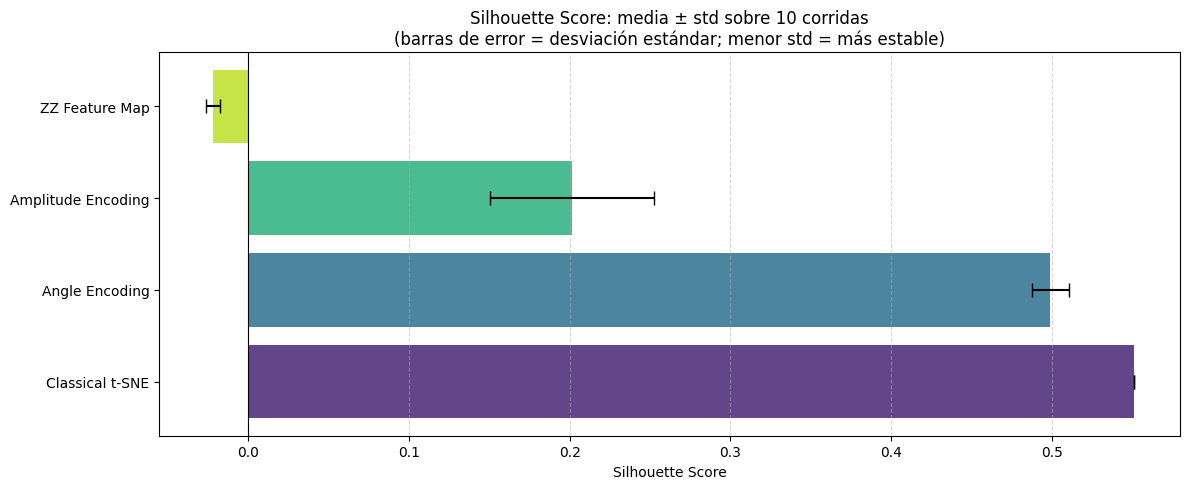

Ranking de estabilidad (menor std = más reproducible):


,Método,Sil_mean,Sil_std
0,Classical t-SNE (PCA-10D),0.550677,0.000000
1,"ZZ Feature Map (4Q, PCA-4)",-0.021938,0.004326
2,"Angle Encoding (13Q, directo)",0.498999,0.011344
3,Amplitude Encoding (4Q),0.201491,0.050846


In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
df_sorted = df_stats.sort_values('Sil_mean', ascending=False)
x_pos  = np.arange(len(df_sorted))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(df_sorted)))

ax.barh(x_pos, df_sorted['Sil_mean'], xerr=df_sorted['Sil_std'],
        align='center', alpha=0.85, capsize=5, color=colors)
ax.set_yticks(x_pos)
ax.set_yticklabels([m.split('(')[0].strip() for m in df_sorted['Método']])
ax.set_xlabel('Silhouette Score')
ax.set_title(f'Silhouette Score: media ± std sobre {N_RUNS} corridas\n'
             '(barras de error = desviación estándar; menor std = más estable)')
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("Ranking de estabilidad (menor std = más reproducible):")
display(df_stats[['Método','Sil_mean','Sil_std']].sort_values('Sil_std').reset_index(drop=True))

## 14. Visualización de los Circuitos Cuánticos Utilizados

Estos son los circuitos reales que `Statevector` ejecuta para calcular cada
entrada de las matrices de kernel.

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.


--- 1. Amplitude Encoding (4 qubits, Wine: 13 → pad 16) ---
  Qubits: 4  |  Profundidad descompuesto: 1
  Gates: {'isometry_to_uncompute_dg': 1}


findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


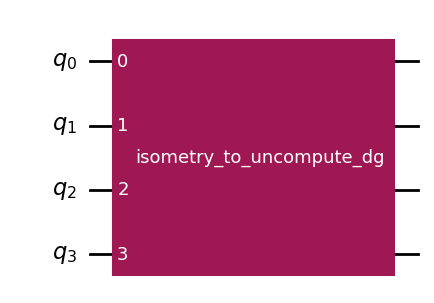


--- 2. Angle Encoding (13 qubits, sin reducción previa) ---
  Qubits: 13  |  Profundidad: 1
  Gates: {'ry': 13}


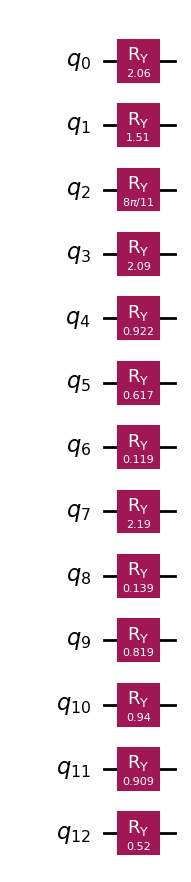


--- 3. ZZ Feature Map (4 qubits, reps=2, PCA-4 previo) ---
  Qubits: 4  |  Profundidad: 31
  Gates: {'cx': 24, 'p': 20, 'h': 8}


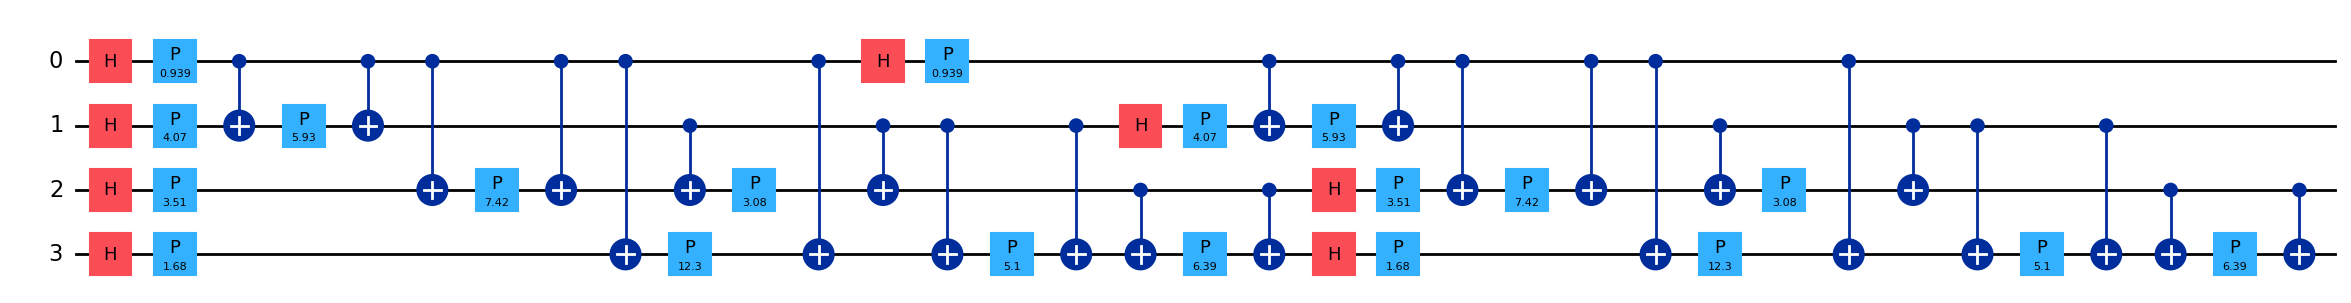

In [16]:
# ── Circuito 1: Amplitude Encoding (4 qubits) ───────────────────────────────
qc_amp     = build_amplitude_circuit(X_amp[0])
qc_amp_dec = qc_amp.decompose()
print("--- 1. Amplitude Encoding (4 qubits, Wine: 13 → pad 16) ---")
print(f"  Qubits: {qc_amp.num_qubits}  |  Profundidad descompuesto: {qc_amp_dec.depth()}")
print(f"  Gates: {dict(qc_amp_dec.count_ops())}")
try:   display(qc_amp_dec.draw('mpl', style='iqp'))
except: print(qc_amp_dec.draw())

# ── Circuito 2: Angle Encoding (13 qubits directos) ─────────────────────────
qc_angle = build_angle_circuit(X_angles[0])
print(f"\n--- 2. Angle Encoding (13 qubits, sin reducción previa) ---")
print(f"  Qubits: {qc_angle.num_qubits}  |  Profundidad: {qc_angle.depth()}")
print(f"  Gates: {dict(qc_angle.count_ops())}")
try:   display(qc_angle.draw('mpl', style='iqp', fold=40))
except: print(qc_angle.draw())

# ── Circuito 3: ZZ Feature Map (4 qubits) ───────────────────────────────────
qc_zz = build_zz_circuit(X_zz[0], n_qubits=N_QUBITS_ZZ)
print(f"\n--- 3. ZZ Feature Map ({N_QUBITS_ZZ} qubits, reps=2, PCA-4 previo) ---")
print(f"  Qubits: {qc_zz.num_qubits}  |  Profundidad: {qc_zz.depth()}")
print(f"  Gates: {dict(qc_zz.count_ops())}")
try:   display(qc_zz.draw('mpl', style='iqp', fold=60))
except: print(qc_zz.draw())

## 15. Resumen y Conclusiones

### Correcciones metodológicas aplicadas

| Punto | Problema en el notebook original | Solución implementada |
|-------|-----------------------------------|-----------------------|
| **1** | Kernels con `np.dot(X,X.T)²` y `∏cos²(Δ/2)` — NumPy puro, sin simulación cuántica | Kernels via `Statevector` de Qiskit — mecánica cuántica exacta en espacio de Hilbert |
| **5** | Un único run con `random_state=42` — sin validez estadística | 10 corridas con semillas distintas — media ± std con boxplots y barras de error |
| **6** | t-SNE clásico sobre PCA vs cuántico sobre datos completos — comparación desigual | Todos los métodos sobre el mismo subconjunto estratificado de N=150; Comparación A aísla el efecto del kernel |

### Ventaja de Wine sobre Cancer para Angle Encoding
Wine tiene 13 features → 13 qubits (2¹³ = 8192 amplitudes, ~65 KB por estado).
Esto permite usar **Angle Encoding directamente sin reducción PCA previa**,
a diferencia del dataset de cáncer (30 qubits → 16 GB, inviable).
Esta es una propiedad importante que debe mencionarse en el análisis.

### Limitaciones
- Ventaja cuántica real solo emerge en hardware cuántico real con d >> 50 qubits.
- En simulación, Statevector implementa la mecánica cuántica exacta pero en CPU.
- Trabajo futuro: accuracy downstream, ejecución en IBM Quantum via Qiskit Runtime.

In [17]:
print("=" * 60)
print("RESUMEN FINAL — Wine Dataset (UCI 109)")
print("=" * 60)
print(f"  Muestras usadas : {N_SAMPLES} (estratificado de {X_full.shape[0]})")
print(f"  Features        : {X_full.shape[1]}")
print(f"  Clases          : {len(np.unique(y))} variedades de vino")
print(f"  Corridas t-SNE  : {N_RUNS} por método")
print()
display(
    df_stats[['Método', 'Sil_mean', 'Silhouette (mean±std)',
              'CH Index (mean±std)', 'DB Index (mean±std)']]
    .sort_values('Sil_mean', ascending=False)
    .drop(columns=['Sil_mean'])
    .reset_index(drop=True)
)

RESUMEN FINAL — Wine Dataset (UCI 109)
  Muestras usadas : 150 (estratificado de 178)
  Features        : 13
  Clases          : 3 variedades de vino
  Corridas t-SNE  : 10 por método



,Método,Silhouette (mean±std),CH Index (mean±std),DB Index (mean±std)
0,Classical t-SNE (PCA-10D),0.5507 ± 0.0000,442.1 ± 0.0,0.5661 ± 0.0000
1,"Angle Encoding (13Q, directo)",0.4990 ± 0.0113,349.9 ± 18.1,0.6422 ± 0.0175
2,Amplitude Encoding (4Q),0.2015 ± 0.0508,42.4 ± 12.4,1.7012 ± 0.6047
3,"ZZ Feature Map (4Q, PCA-4)",-0.0219 ± 0.0043,2.8 ± 2.5,11.8012 ± 10.7106
